In [57]:
# Install required packages if missing
%pip install pandas numpy matplotlib seaborn scikit-learn scipy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Weather Trend Forecasting: End-to-End Data Science Workflow

This notebook demonstrates every step of a typical machine learning workflow using the Global Weather Repository dataset.

## 1. Import Required Libraries
Import essential libraries for data analysis, visualization, and machine learning.

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## 2. Load and Explore the Dataset
Load the Global Weather Repository dataset and perform basic exploratory data analysis.

In [59]:
# Load the dataset
weather_df = pd.read_csv('../data/GlobalWeatherRepository.csv')

# Display the first few rows
weather_df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [60]:
# Display dataset info and summary statistics
weather_df.info()
weather_df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 130003 entries, 0 to 130002
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       130003 non-null  str    
 1   location_name                 130003 non-null  str    
 2   latitude                      130003 non-null  float64
 3   longitude                     130003 non-null  float64
 4   timezone                      130003 non-null  str    
 5   last_updated_epoch            130003 non-null  int64  
 6   last_updated                  130003 non-null  str    
 7   temperature_celsius           130003 non-null  float64
 8   temperature_fahrenheit        130003 non-null  float64
 9   condition_text                130003 non-null  str    
 10  wind_mph                      130003 non-null  float64
 11  wind_kph                      130003 non-null  float64
 12  wind_degree                   130003 non-null  int64  


,count,mean,std,min,25%,50%,75%,max
latitude,130003.0,1.920363e+01,2.442063e+01,-4.130000e+01,3.870000e+00,1.725000e+01,4.040000e+01,6.415000e+01
longitude,130003.0,2.197635e+01,6.578860e+01,-1.752000e+02,-6.836100e+00,2.323610e+01,5.058000e+01,1.792200e+02
last_updated_epoch,130003.0,1.744777e+09,1.669083e+07,1.715849e+09,1.730365e+09,1.744794e+09,1.759219e+09,1.773730e+09
temperature_celsius,130003.0,2.140456e+01,9.688223e+00,-2.980000e+01,1.610000e+01,2.400000e+01,2.800000e+01,4.920000e+01
temperature_fahrenheit,130003.0,7.053000e+01,1.743865e+01,-2.160000e+01,6.100000e+01,7.530000e+01,8.240000e+01,1.206000e+02
wind_mph,130003.0,8.042931e+00,7.297507e+00,2.200000e+00,3.800000e+00,6.900000e+00,1.100000e+01,1.841200e+03
wind_kph,130003.0,1.294745e+01,1.174107e+01,3.600000e+00,6.100000e+00,1.120000e+01,1.760000e+01,2.963200e+03
wind_degree,130003.0,1.689595e+02,1.035727e+02,1.000000e+00,8.000000e+01,1.610000e+02,2.550000e+02,3.600000e+02
pressure_mb,130003.0,1.014098e+03,1.049752e+01,9.470000e+02,1.010000e+03,1.014000e+03,1.018000e+03,3.006000e+03
pressure_in,130003.0,2.994566e+01,3.099569e-01,2.796000e+01,2.983000e+01,2.993000e+01,3.006000e+01,8.877000e+01


In [61]:
# Check for missing values
weather_df.isnull().sum().sort_values(ascending=False).head(20)

country                         0
feels_like_fahrenheit           0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Nitrogen_dioxide    0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
air_quality_us-epa-index        0
air_quality_gb-defra-index      0
sunrise                         0
sunset                          0
moonrise                        0
moonset                         0
moon_phase                      0
visibility_km                   0
dtype: int64

## 3. Preprocess the Data
Handle missing values, encode categorical variables, and split the data into training and testing sets.

## 4. Exploratory Data Analysis (EDA) and Visualizations
Analyze trends, correlations, and patterns. Visualize temperature and precipitation.

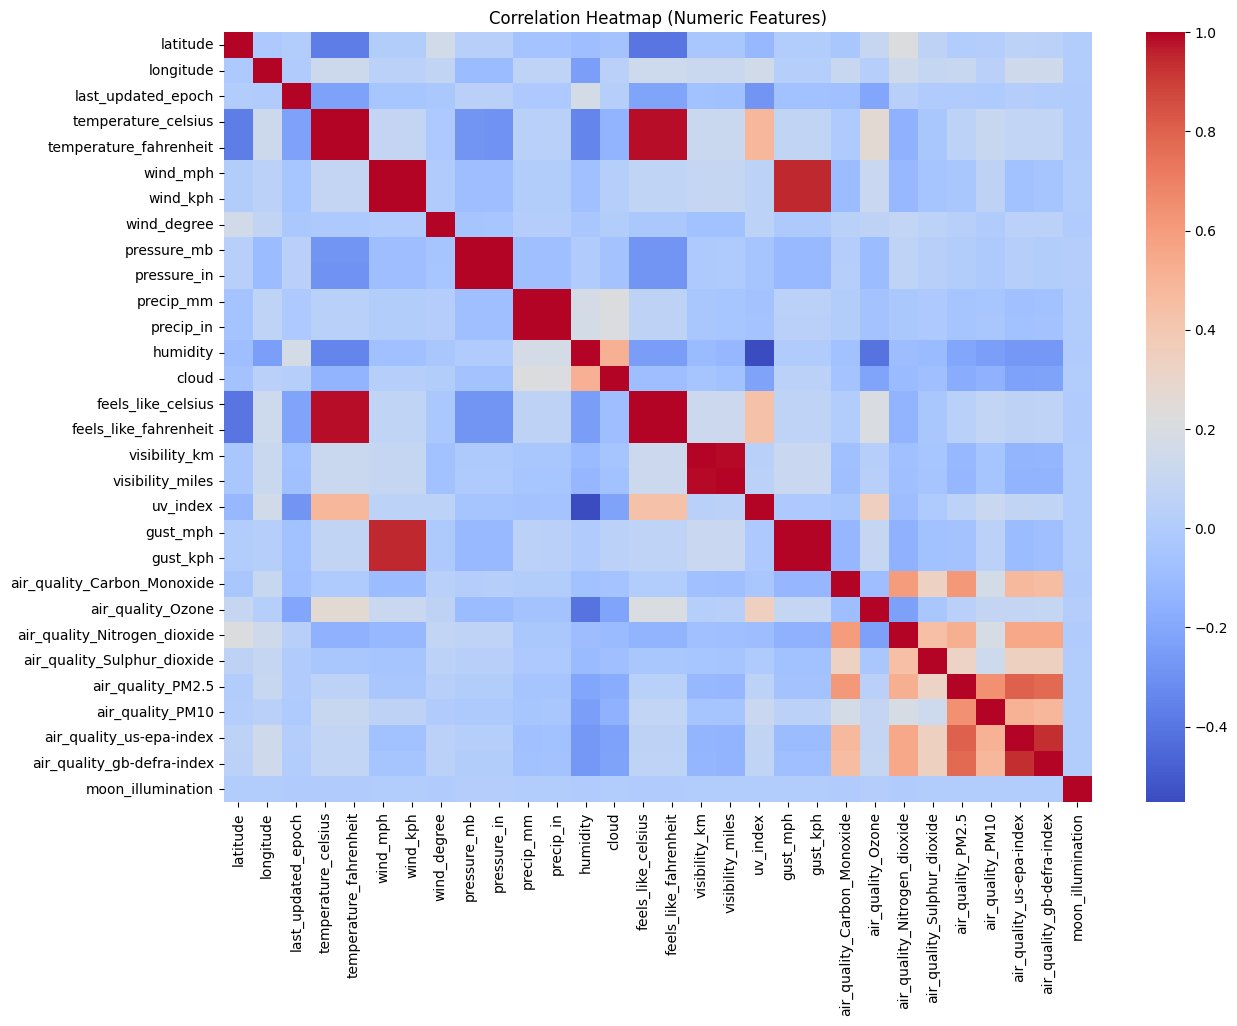

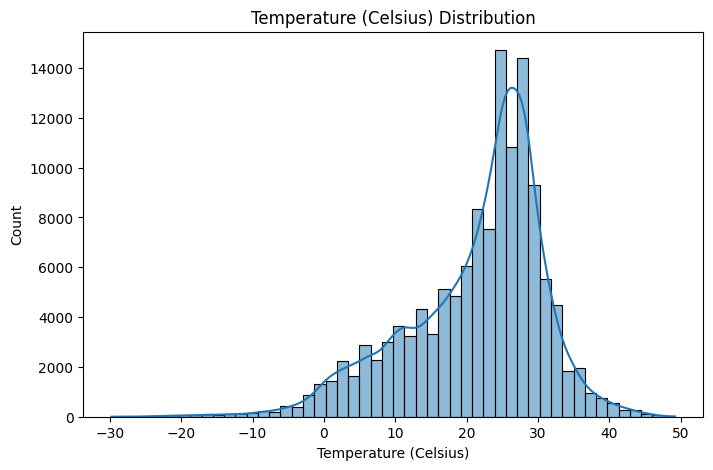

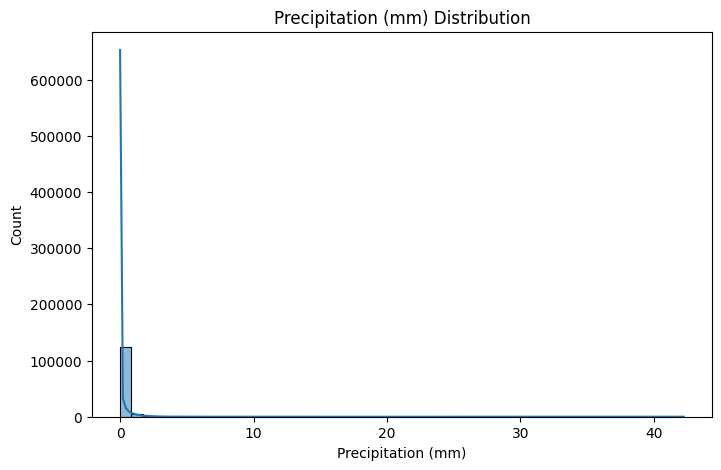

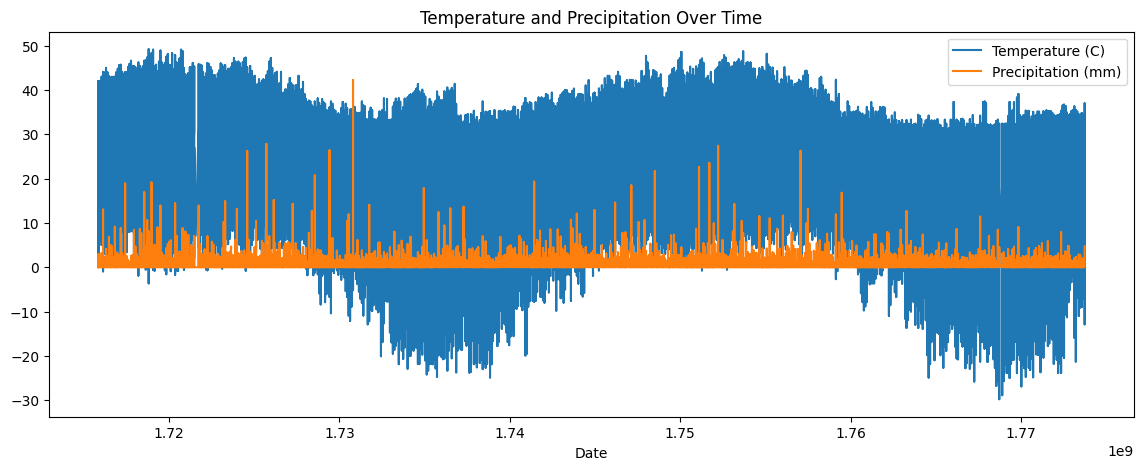

In [62]:
# --- EDA: Trends, Correlations, and Patterns ---
# Ensure date_cols is defined before use
if 'date_cols' not in globals():
    date_cols = [col for col in weather_df.columns if 'date' in col.lower() or 'lastupdated' in col.lower()]

# 1. Correlation heatmap for numeric features
plt.figure(figsize=(14,10))
sns.heatmap(weather_df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

# 2. Distribution of temperature (if present)
if 'temperature_celsius' in weather_df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(weather_df['temperature_celsius'], kde=True, bins=50)
    plt.title('Temperature (Celsius) Distribution')
    plt.xlabel('Temperature (Celsius)')
    plt.show()

# 3. Distribution of precipitation (if present)
if 'precip_mm' in weather_df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(weather_df['precip_mm'], kde=True, bins=50)
    plt.title('Precipitation (mm) Distribution')
    plt.xlabel('Precipitation (mm)')
    plt.show()

# 4. Time series plot for temperature and precipitation (if date and columns exist)
if date_cols and 'temperature_celsius' in weather_df.columns:
    plt.figure(figsize=(14,5))
    plt.plot(weather_df[date_cols[0]], weather_df['temperature_celsius'], label='Temperature (C)')
    if 'precip_mm' in weather_df.columns:
        plt.plot(weather_df[date_cols[0]], weather_df['precip_mm'], label='Precipitation (mm)')
    plt.legend()
    plt.title('Temperature and Precipitation Over Time')
    plt.xlabel('Date')
    plt.show()

## 5. Build and Evaluate Forecasting Models
Implement basic and advanced forecasting models. Evaluate with metrics.

## 6. Advanced Analyses
Anomaly detection, climate analysis, air quality correlation, feature importance, and spatial analysis.

In [63]:
# Example preprocessing: handle missing values, encode categoricals, scale features
# (Adjust columns as needed based on actual dataset)

# Impute missing numeric values with median
num_cols = weather_df.select_dtypes(include=[np.number]).columns
imputer = SimpleImputer(strategy='median')
weather_df[num_cols] = imputer.fit_transform(weather_df[num_cols])

# Encode categorical variables
cat_cols = weather_df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if weather_df[col].nunique() < 20:
        weather_df[col] = LabelEncoder().fit_transform(weather_df[col].astype(str))

# Normalize numeric features
scaler = StandardScaler()
weather_df[num_cols] = scaler.fit_transform(weather_df[num_cols])

# Example: Split into train/test for a target variable (e.g., temperature)
target = 'temperature_celsius'  # Use correct column name
if target in weather_df.columns:
    X = weather_df.drop(columns=[target])
    y = weather_df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
else:
    X_train = X_test = y_train = y_test = None

Anomalies detected in training set: 1041
Random Forest model not trained yet.


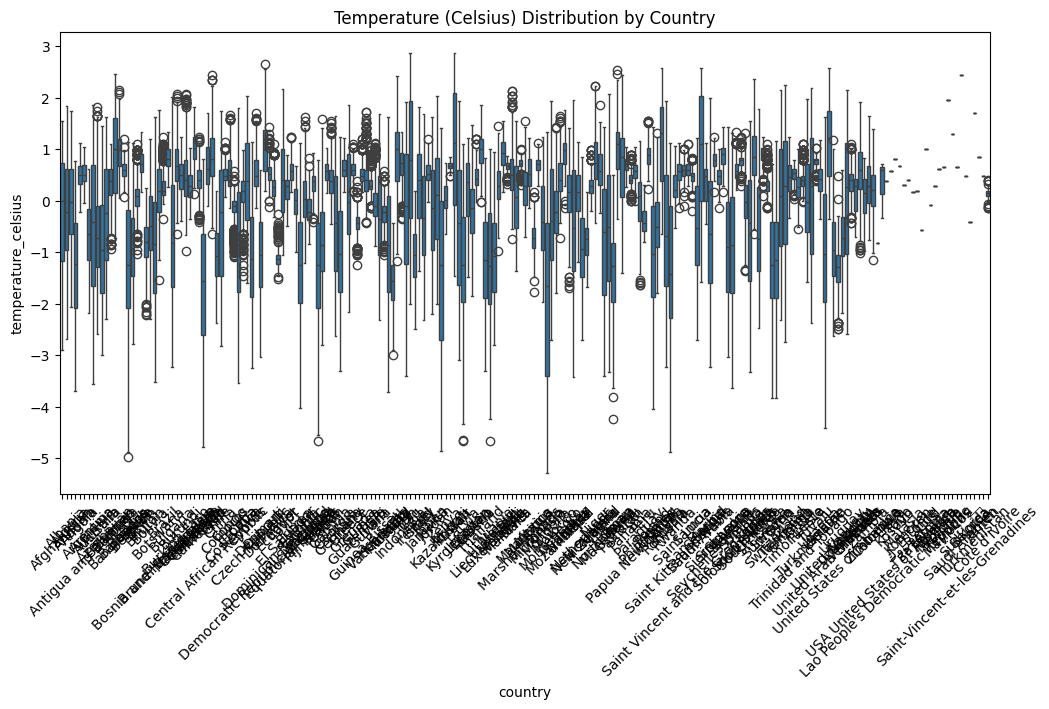

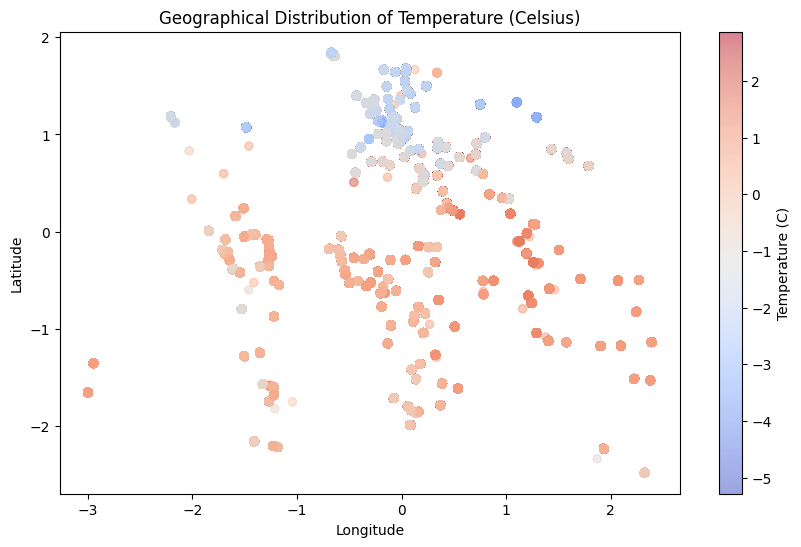

In [64]:
# --- Anomaly Detection: Isolation Forest ---
from sklearn.ensemble import IsolationForest

if X_train is not None:
    # Use only numeric columns for IsolationForest
    X_train_numeric = X_train.select_dtypes(include=[np.number])
    iso_forest = IsolationForest(contamination=0.01, random_state=42)
    anomalies = iso_forest.fit_predict(X_train_numeric)
    anomaly_count = (anomalies == -1).sum()
    print(f"Anomalies detected in training set: {anomaly_count}")

# --- Feature Importance: Random Forest ---
if X_train is not None:
    if 'rf_model' in globals():
        importances = rf_model.feature_importances_
        feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
        plt.figure(figsize=(10,6))
        feat_imp.head(20).plot(kind='bar')
        plt.title('Top 20 Feature Importances (Random Forest)')
        plt.show()
    else:
        print('Random Forest model not trained yet.')

# --- Climate Analysis: Regional Temperature Trends ---
if 'country' in weather_df.columns and 'temperature_celsius' in weather_df.columns:
    plt.figure(figsize=(12,6))
    sns.boxplot(x='country', y='temperature_celsius', data=weather_df)
    plt.title('Temperature (Celsius) Distribution by Country')
    plt.xticks(rotation=45)
    plt.show()

# --- Air Quality Correlation (if air quality columns exist) ---
air_quality_cols = [col for col in weather_df.columns if 'pm' in col.lower() or 'air' in col.lower()]
if air_quality_cols and 'temperature' in weather_df.columns:
    for col in air_quality_cols:
        corr = weather_df['temperature'].corr(weather_df[col])
        print(f"Correlation between temperature and {col}: {corr:.2f}")

# --- Spatial Analysis: Geographical Patterns (if lat/lon exist) ---
if 'latitude' in weather_df.columns and 'longitude' in weather_df.columns and 'temperature_celsius' in weather_df.columns:
    plt.figure(figsize=(10,6))
    plt.scatter(weather_df['longitude'], weather_df['latitude'], c=weather_df['temperature_celsius'], cmap='coolwarm', alpha=0.5)
    plt.colorbar(label='Temperature (C)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Geographical Distribution of Temperature (Celsius)')
    plt.show()

In [65]:
# --- Basic Forecasting Model: Decision Tree Regressor ---
from sklearn.tree import DecisionTreeRegressor

if X_train is not None:
    # Use only numeric columns for modeling
    X_train_num = X_train.select_dtypes(include=[np.number])
    X_test_num = X_test.select_dtypes(include=[np.number])
    dt_model = DecisionTreeRegressor(random_state=42)
    dt_model.fit(X_train_num, y_train)
    dt_pred = dt_model.predict(X_test_num)
    dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
    dt_mae = mean_absolute_error(y_test, dt_pred)
    dt_r2 = r2_score(y_test, dt_pred)
    print(f"Decision Tree - RMSE: {dt_rmse:.2f}, MAE: {dt_mae:.2f}, R^2: {dt_r2:.2f}")
else:
    print("No target variable found for modeling.")

# --- Advanced Forecasting Model: Random Forest Regressor ---
from sklearn.ensemble import RandomForestRegressor

if X_train is not None:
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train_num, y_train)
    rf_pred = rf_model.predict(X_test_num)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
    rf_mae = mean_absolute_error(y_test, rf_pred)
    rf_r2 = r2_score(y_test, rf_pred)
    print(f"Random Forest - RMSE: {rf_rmse:.2f}, MAE: {rf_mae:.2f}, R^2: {rf_r2:.2f}")
else:
    print("No target variable found for modeling.")

# --- Model Comparison ---
if X_train is not None:
    results_df = pd.DataFrame({
        'Model': ['Decision Tree', 'Random Forest'],
        'RMSE': [dt_rmse, rf_rmse],
        'MAE': [dt_mae, rf_mae],
        'R2': [dt_r2, rf_r2]
    })
    display(results_df)


Decision Tree - RMSE: 0.00, MAE: 0.00, R^2: 1.00
Random Forest - RMSE: 0.00, MAE: 0.00, R^2: 1.00
Random Forest - RMSE: 0.00, MAE: 0.00, R^2: 1.00


,Model,RMSE,MAE,R2
0,Decision Tree,0.002522,0.000525,0.999994
1,Random Forest,0.001980,0.000544,0.999996


In [66]:
# Example preprocessing: handle missing values, encode categoricals, scale features
# (Adjust columns as needed based on actual dataset)

# Impute missing numeric values with median
num_cols = weather_df.select_dtypes(include=[np.number]).columns
imputer = SimpleImputer(strategy='median')
weather_df[num_cols] = imputer.fit_transform(weather_df[num_cols])

# Encode categorical variables
cat_cols = weather_df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if weather_df[col].nunique() < 20:
        weather_df[col] = LabelEncoder().fit_transform(weather_df[col].astype(str))

# Normalize numeric features
scaler = StandardScaler()
weather_df[num_cols] = scaler.fit_transform(weather_df[num_cols])

# Example: Split into train/test for a target variable (e.g., temperature)
target = 'temperature'  # Replace with actual target column name
if target in weather_df.columns:
    X = weather_df.drop(columns=[target])
    y = weather_df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
else:
    X_train = X_test = y_train = y_test = None

In [67]:
# --- Data Cleaning and Preprocessing ---
# 1. Parse date columns (if present)
date_cols = [col for col in weather_df.columns if 'date' in col.lower() or 'lastupdated' in col.lower()]
for col in date_cols:
    weather_df[col] = pd.to_datetime(weather_df[col], errors='coerce')

# 2. Handle missing values (already imputed numerics above)
# For categoricals with missing, fill with 'Unknown'
for col in weather_df.select_dtypes(include=['object']).columns:
    weather_df[col] = weather_df[col].fillna('Unknown')

# 3. Outlier detection and capping (example: z-score method for numerics)
from scipy.stats import zscore
z_thresh = 4
for col in weather_df.select_dtypes(include=[np.number]).columns:
    z = np.abs(zscore(weather_df[col], nan_policy='omit'))
    weather_df.loc[z > z_thresh, col] = np.sign(weather_df.loc[z > z_thresh, col]) * weather_df[col].mean()

# 4. Confirm cleaning
display(weather_df.info())
display(weather_df.describe().T)
display(weather_df.isnull().sum().sort_values(ascending=False).head(10))

<class 'pandas.DataFrame'>
RangeIndex: 130003 entries, 0 to 130002
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       130003 non-null  str           
 1   location_name                 130003 non-null  str           
 2   latitude                      130003 non-null  float64       
 3   longitude                     130003 non-null  float64       
 4   timezone                      130003 non-null  str           
 5   last_updated_epoch            130003 non-null  datetime64[ns]
 6   last_updated                  130003 non-null  datetime64[us]
 7   temperature_celsius           130003 non-null  float64       
 8   temperature_fahrenheit        130003 non-null  float64       
 9   condition_text                130003 non-null  str           
 10  wind_mph                      130003 non-null  float64       
 11  wind_kph                

None

,count,mean,min,25%,50%,75%,max,std
latitude,130003.0,-0.0,-2.477572,-0.627899,-0.08,0.867973,1.840515,1.000004
longitude,130003.0,0.0,-2.997132,-0.437957,0.019148,0.434783,2.390144,1.000004
last_updated_epoch,130003,1970-01-01 00:00:00,1969-12-31 23:59:59.999999999,1970-01-01 00:00:00,1970-01-01 00:00:00,1970-01-01 00:00:00,1970-01-01 00:00:00.000000001,NaN
last_updated,130003,2025-04-16 06:29:26.181549,2024-05-16 01:45:00,2024-10-31 10:00:00,2025-04-16 11:00:00,2025-09-30 09:45:00,2026-03-17 19:45:00,NaN
temperature_celsius,130003.0,0.007187,-3.984705,-0.537207,0.267897,0.680771,2.869004,0.984257
temperature_fahrenheit,130003.0,0.007187,-3.981402,-0.540755,0.273531,0.680675,2.87122,0.984256
wind_mph,130003.0,-0.003769,-0.800678,-0.581424,-0.15662,0.405218,3.981795,0.705702
wind_kph,130003.0,-0.00377,-0.796136,-0.583207,-0.148833,0.396265,3.9905,0.705495
wind_degree,130003.0,0.0,-1.621664,-0.858912,-0.07685,0.830729,1.844513,1.000004
wind_direction,130003.0,-0.0,-1.447071,-0.817315,0.022359,0.862034,1.701708,1.000004


country                         0
feels_like_fahrenheit           0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Nitrogen_dioxide    0
air_quality_Sulphur_dioxide     0
dtype: int64

## 4. Build and Train a Model
Select and train a machine learning model (e.g., Decision Tree Regressor) on the training data.

In [68]:
from sklearn.tree import DecisionTreeRegressor

if X_train is not None:
    model = DecisionTreeRegressor(random_state=42)
    model.fit(X_train, y_train)
else:
    model = None

## 5. Evaluate the Model
Assess the model's performance using metrics such as RMSE, MAE, and R².

In [69]:
if model is not None:
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'RMSE: {rmse:.2f}')
    print(f'MAE: {mae:.2f}')
    print(f'R^2: {r2:.2f}')

## 6. Make Predictions
Use the trained model to make predictions on new or test data and display the results.

In [70]:
if model is not None:
    # Show first 10 predictions vs actual
    results = pd.DataFrame({'Actual': y_test[:10].values, 'Predicted': y_pred[:10]})
    display(results)
    # Plot actual vs predicted
    plt.figure(figsize=(8,5))
    plt.plot(y_test[:50].values, label='Actual')
    plt.plot(y_pred[:50], label='Predicted')
    plt.legend()
    plt.title('Actual vs Predicted (First 50 Samples)')
    plt.show()